# Causal Inference: Do High Gender Quotas Affect Female Representation in Diplomatic Images?

1. **Descriptive relationship (association):** Visualize `female_ratio` across quota levels.
2. **Design choice:** Use a *cleaner* treatment definition to avoid sparse quota categories.
3. **Causal estimators (adjusted):** Propensity score → overlap check → matching / IPW / POM, plus a regression-adjusted check.
4. **Conclusion:** Interpret effect size + uncertainty (CI / p-value), rather than relying on raw plots alone.

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.formula.api as smf
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from patsy import dmatrix


In [ ]:
DATA_PATH = "country_year_women_ratio_vdem_multi.csv"
df = pd.read_csv(DATA_PATH)

print("Rows:", len(df))
print("Columns:", len(df.columns))
df.head()


Rows: 1359
Columns: 17


,country,year,n_news,n_images_people,male_total,female_total,people_total,female_ratio,v2x_polyarchy,v2x_libdem,v2x_egaldem,v2fsuffrage,v2lgqugen,v2lgfemleg,v2x_civlib,v2x_clpol,v2x_clphy
0,AGO,2022,304,304,1638,445,2083,0.213634,0.327,0.154,0.132,100.0,1.0,33.64,0.602,0.573,0.652
1,AGO,2023,300,300,1531,356,1887,0.188659,0.330,0.157,0.140,100.0,1.0,33.64,0.598,0.559,0.652
2,AGO,2024,269,269,1422,309,1731,0.178510,0.340,0.164,0.138,100.0,1.0,39.60,0.624,0.593,0.699
3,ALB,2017,11,11,65,15,80,0.187500,0.537,0.440,0.384,100.0,2.0,27.86,0.889,0.836,0.958
4,ALB,2022,1,2,4,0,4,0.000000,0.520,0.433,0.390,100.0,2.0,35.70,0.886,0.806,0.934


## 1) Descriptive relationship: quota level vs `female_ratio`


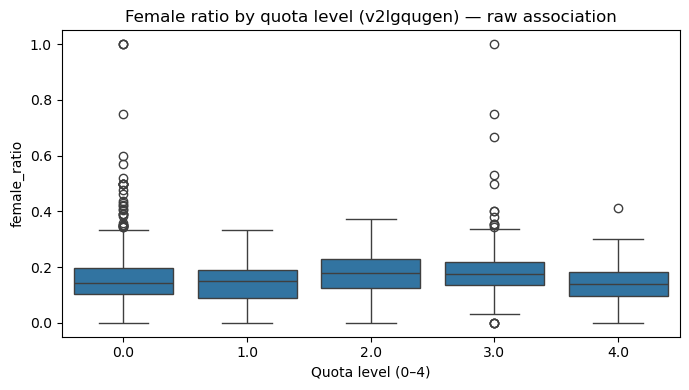

Mean female_ratio by quota level:
v2lgqugen
0.0    0.160697
1.0    0.139917
2.0    0.183597
3.0    0.185210
4.0    0.138585
Name: female_ratio, dtype: float64


In [ ]:
df_plot = df.copy()
df_plot["v2lgqugen"] = pd.to_numeric(df_plot["v2lgqugen"], errors="coerce")
df_plot["female_ratio"] = pd.to_numeric(df_plot["female_ratio"], errors="coerce")
df_plot = df_plot.dropna(subset=["v2lgqugen", "female_ratio"]).copy()

plt.figure(figsize=(7,4))
sns.boxplot(x="v2lgqugen", y="female_ratio", data=df_plot)
plt.title("Female ratio by quota level (v2lgqugen) — raw association")
plt.xlabel("Quota level (0–4)")
plt.ylabel("female_ratio")
plt.tight_layout()
plt.show()

print("Mean female_ratio by quota level:")
print(df_plot.groupby("v2lgqugen")["female_ratio"].mean())


## 2) Exclude quota levels 1–2
 * since **1** and **2** are relatively rare in this dataset.


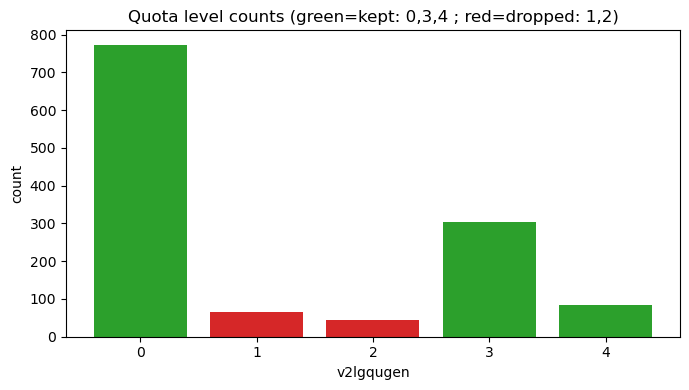

Counts by quota level:
v2lgqugen
0.0    773
1.0     66
2.0     43
3.0    303
4.0     85
Name: count, dtype: int64


In [ ]:
tmp = df.copy()
tmp["v2lgqugen"] = pd.to_numeric(tmp["v2lgqugen"], errors="coerce")
tmp = tmp.dropna(subset=["v2lgqugen"]).copy()

counts = tmp["v2lgqugen"].value_counts().sort_index()

keep_levels = {0, 3, 4}
colors = ["tab:green" if lvl in keep_levels else "tab:red" for lvl in counts.index]

plt.figure(figsize=(7,4))
plt.bar(counts.index.astype(int), counts.values, color=colors)
plt.title("Quota level counts (green=kept: 0,3,4 ; red=dropped: 1,2)")
plt.xlabel("v2lgqugen")
plt.ylabel("count")
plt.xticks(counts.index.astype(int))
plt.tight_layout()
plt.show()

print("Counts by quota level:")
print(counts)


## Sanity check: 0 vs 3 vs 4

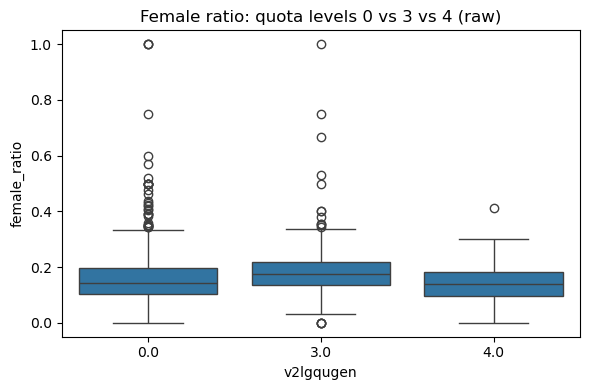

Means (0,3,4):
v2lgqugen
0.0    0.160697
3.0    0.185210
4.0    0.138585
Name: female_ratio, dtype: float64


In [ ]:
sub = df_plot[df_plot["v2lgqugen"].isin([0,3,4])].copy()

plt.figure(figsize=(6,4))
sns.boxplot(x="v2lgqugen", y="female_ratio", data=sub)
plt.title("Female ratio: quota levels 0 vs 3 vs 4 (raw)")
plt.xlabel("v2lgqugen")
plt.ylabel("female_ratio")
plt.tight_layout()
plt.show()

print("Means (0,3,4):")
print(sub.groupby("v2lgqugen")["female_ratio"].mean())


## 3) Build treatment and analysis dataset


In [ ]:
d = df.copy()
d["v2lgqugen"] = pd.to_numeric(d["v2lgqugen"], errors="coerce")
d["female_ratio"] = pd.to_numeric(d["female_ratio"], errors="coerce")

# Treatment: 0 if quota==0, 1 if quota in {3,4}, else NaN (drop 1–2)
d["intervention"] = pd.Series(pd.NA, index=d.index, dtype="Int64")
d.loc[d["v2lgqugen"] == 0, "intervention"] = 0
d.loc[d["v2lgqugen"].isin([3,4]), "intervention"] = 1

d = d.dropna(subset=["intervention", "female_ratio"]).copy()
d["intervention"] = d["intervention"].astype(int)

print("Rows used:", len(d))
print("Treatment counts:\n", d["intervention"].value_counts().sort_index())
d.head()


Rows used: 1161
Treatment counts:
 intervention
0    773
1    388
Name: count, dtype: int64


,country,year,n_news,n_images_people,male_total,female_total,people_total,female_ratio,v2x_polyarchy,v2x_libdem,v2x_egaldem,v2fsuffrage,v2lgqugen,v2lgfemleg,v2x_civlib,v2x_clpol,v2x_clphy,intervention
22,ARE,2024,1,1,1,0,1,0.000000,0.103,0.078,0.125,36.0,4.0,50.00,0.351,0.118,0.643,1
23,ARG,2015,76,284,1198,191,1389,0.137509,0.776,0.601,0.613,100.0,3.0,35.80,0.879,0.883,0.839,1
24,ARG,2016,441,1852,9874,2086,11960,0.174415,0.753,0.616,0.598,100.0,3.0,38.91,0.892,0.921,0.843,1
25,ARG,2017,487,1841,9231,1612,10843,0.148667,0.754,0.612,0.584,100.0,3.0,38.91,0.875,0.914,0.794,1
26,ARG,2018,389,1370,6975,1168,8143,0.143436,0.783,0.637,0.621,100.0,3.0,38.82,0.891,0.910,0.842,1


## 4) Naive difference (unadjusted)

Simple mean difference between groups.

In [ ]:
mean_treated = d[d["intervention"] == 1]["female_ratio"].mean()
mean_untreated = d[d["intervention"] == 0]["female_ratio"].mean()
naive_ate = mean_treated - mean_untreated

print(f"Mean (Treated=High 3–4): {mean_treated:.6f}")
print(f"Mean (Untreated=None 0): {mean_untreated:.6f}")
print(f"Naive difference (High - None): {naive_ate:.6f}")


Mean (Treated=High 3–4): 0.174996
Mean (Untreated=None 0): 0.160697
Naive difference (High - None): 0.014298


## 5) Propensity score model

In [ ]:
candidate_X = ["year", "v2x_libdem", "v2x_civlib", "v2x_egaldem", "v2fsuffrage", "v2lgfemleg", "v2x_polyarchy"]
X_cols = [c for c in candidate_X if c in d.columns]

for c in X_cols:
    d[c] = pd.to_numeric(d[c], errors="coerce")

d_ps = d.dropna(subset=X_cols).copy()

print("Covariates used:", X_cols)
print("Rows for PS model:", len(d_ps))


Covariates used: ['year', 'v2x_libdem', 'v2x_civlib', 'v2x_egaldem', 'v2fsuffrage', 'v2lgfemleg', 'v2x_polyarchy']
Rows for PS model: 1154


In [ ]:
ps_formula = "intervention ~ " + " + ".join(X_cols)
ps_model = smf.logit(ps_formula, data=d_ps).fit(disp=0)

d_ps = d_ps.assign(propensity_score = ps_model.predict(d_ps))

print("Propensity Score Distribution:")
print(d_ps["propensity_score"].describe())


Propensity Score Distribution:
count    1154.000000
mean        0.334489
std         0.260179
min         0.000723
25%         0.114577
50%         0.262972
75%         0.511427
max         0.970304
Name: propensity_score, dtype: float64


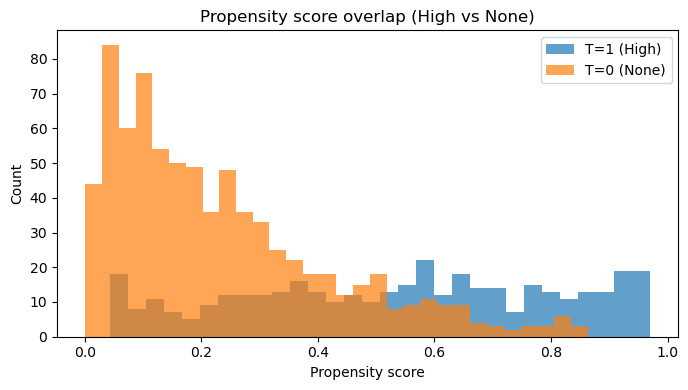

In [ ]:
plt.figure(figsize=(7,4))
plt.hist(d_ps.query("intervention==1")["propensity_score"], bins=30, alpha=0.7, label="T=1 (High)")
plt.hist(d_ps.query("intervention==0")["propensity_score"], bins=30, alpha=0.7, label="T=0 (None)")
plt.xlabel("Propensity score")
plt.ylabel("Count")
plt.title("Propensity score overlap (High vs None)")
plt.legend()
plt.tight_layout()
plt.show()


## 6) Propensity score matching (1-NN on propensity)

In [ ]:
T = "intervention"
X = "propensity_score"
Y = "female_ratio"

treated = d_ps.query(f"{T}==1")
untreated = d_ps.query(f"{T}==0")

print(f"Treated units: {len(treated)}")
print(f"Control units: {len(untreated)}")

mt0 = KNeighborsRegressor(n_neighbors=1).fit(untreated[[X]], untreated[Y])
mt1 = KNeighborsRegressor(n_neighbors=1).fit(treated[[X]], treated[Y])

predicted = pd.concat([
    treated.assign(match = mt0.predict(treated[[X]])),
    untreated.assign(match = mt1.predict(untreated[[X]]))
], ignore_index=True)

matching_ate = np.mean(
    (predicted[Y] - predicted["match"]) * predicted[T] +
    (predicted["match"] - predicted[Y]) * (1 - predicted[T])
)

print(f"Matching ATE: {matching_ate:.6f}")


Treated units: 386
Control units: 768
Matching ATE: -0.007077


## 7) Inverse Propensity Weighting (IPW)

In [ ]:
# Unstabilized weights
wt = 1 / d_ps.query("intervention==1")["propensity_score"]
w0 = 1 / (1 - d_ps.query("intervention==0")["propensity_score"])

y1 = d_ps.query("intervention==1")[Y]
y0 = d_ps.query("intervention==0")[Y]

n = len(d_ps)
E_Y1 = np.sum(y1 * wt) / n
E_Y0 = np.sum(y0 * w0) / n
ipw_ate = E_Y1 - E_Y0

print(f"E[Y1] (everyone treated):   {E_Y1:.6f}")
print(f"E[Y0] (everyone untreated): {E_Y0:.6f}")
print(f"IPW ATE:                    {ipw_ate:.6f}")


E[Y1] (everyone treated):   0.170735
E[Y0] (everyone untreated): 0.160386
IPW ATE:                    0.010349


## 8) Potential Outcome Modelling (POM)

In [ ]:
def pom(df_in, formula_x, Tcol, Ycol):
    Xmat = dmatrix(formula_x, df_in)
    m0 = LinearRegression().fit(Xmat[df_in[Tcol]==0, :], df_in.query(f"{Tcol}==0")[Ycol])
    m1 = LinearRegression().fit(Xmat[df_in[Tcol]==1, :], df_in.query(f"{Tcol}==1")[Ycol])

    m0_hat = m0.predict(Xmat)
    m1_hat = m1.predict(Xmat)
    ate = np.mean(m1_hat) - np.mean(m0_hat)
    return pd.DataFrame({"m0": m0_hat, "m1": m1_hat}), ate

formula_x = " + ".join(X_cols)
pom_df, pom_ate = pom(d_ps, formula_x, T, Y)

print(f"POM ATE: {pom_ate:.6f}")
pom_df.head()


POM ATE: -0.008843


,m0,m1
0,0.237368,0.116099
1,0.178174,0.165265
2,0.202195,0.174915
3,0.206620,0.181793
4,0.203720,0.187330


## 9) Regression adjustment (OLS) + uncertainty (p-value / CI)

In [ ]:
# Try to use country-level clustering if a country id column exists
country_col = None
for c in ["country", "country_text_id", "Country", "country_code"]:
    if c in d_ps.columns:
        country_col = c
        break

ols_formula = "female_ratio ~ intervention + " + " + ".join(X_cols)

if country_col is not None:
    m = smf.ols(ols_formula, data=d_ps).fit(cov_type="cluster", cov_kwds={"groups": d_ps[country_col]})
    se_type = f"cluster-robust (by {country_col})"
else:
    m = smf.ols(ols_formula, data=d_ps).fit(cov_type="HC1")
    se_type = "robust (HC1)"

tau = m.params["intervention"]
se  = m.bse["intervention"]
p   = m.pvalues["intervention"]
ci  = (tau - 1.96*se, tau + 1.96*se)

print("SE type:", se_type)
print("OLS adjusted effect (coef on intervention):", float(tau))
print("SE:", float(se))
print("p-value:", float(p))
print("95% CI:", (float(ci[0]), float(ci[1])))


SE type: cluster-robust (by country)
OLS adjusted effect (coef on intervention): -0.006461168142366356
SE: 0.013070957261612517
p-value: 0.6210838464956259
95% CI: (-0.03208024437512689, 0.01915790809039418)


## 10) Summary table

In [ ]:
summary = pd.DataFrame({
    "method": [
        "Naive (raw mean diff)",
        "PS Matching (1-NN)",
        "IPW",
        "POM",
        "OLS (regression adjustment)"
    ],
    "ATE_or_coef": [
        naive_ate,
        matching_ate,
        ipw_ate,
        pom_ate,
        tau
    ]
})

summary


,method,ATE_or_coef
0,Naive (raw mean diff),0.014298
1,PS Matching (1-NN),-0.007077
2,IPW,0.010349
3,POM,-0.008843
4,OLS (regression adjustment),-0.006461
